In [3]:
import pandas as pd
import numpy as np
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [ ]:
path = '.../KDDTrain+.arff'
data, meta = arff.loadarff(path)
df = pd.DataFrame(data)
for col in df.select_dtypes([object]):
    df[col] = df[col].str.decode('utf-8')
df['label'] = (df[df.columns[-1]] != 'normal').astype(int)


In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct.round(2)
})

missing_cols = missing_df[missing_df['Missing Count'] > 0]

if missing_cols.empty:
    print("No missing values found.")
else:
    print(f"Missing values found in {len(missing_cols)} column(s):\n")
    print(missing_cols.to_string())

print(f"Total rows       : {len(df)}")
print(f"Total columns    : {df.shape[1]}")
print(f"Total missing    : {df.isnull().sum().sum()}")
print(f"Affected columns : {len(missing_cols)}")

No missing values found.
Total rows       : 125973
Total columns    : 43
Total missing    : 0
Affected columns : 0


In [7]:
selected_features = [
    'num_access_files',
    'dst_bytes',
    'dst_host_count',
    'num_compromised',
    'dst_host_same_srv_rate',
    'same_srv_rate',
    'dst_host_srv_count',
    'serror_rate',
    'count',
    'rerror_rate',
    'dst_host_srv_rerror_rate',
    'dst_host_srv_serror_rate',
    'dst_host_rerror_rate',
    'dst_host_same_src_port_rate',
    'dst_host_serror_rate',
    'num_file_creations',
    'srv_count',
    'srv_serror_rate',
    'srv_rerror_rate',
    'srv_diff_host_rate',
    'wrong_fragment',
    'urgent',
    'src_bytes',
    'hot',
    'num_failed_logins'
]

print(f"Total features: {len(selected_features)}")

Total features: 25


In [8]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['protocol_type'] = label_encoder.fit_transform(df['protocol_type'])
df['flag'] = label_encoder.fit_transform(df['flag'])

In [9]:

X = df[selected_features].values
y = df.iloc[:, 42].values


In [10]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [11]:
import tensorflow as tf
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]
y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

In [12]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, TimeDistributed, Lambda
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
class JaspenCorrelation(tf.keras.layers.Layer):
    def call(self, inputs):
        t, r = inputs  # t: (None, feat_dim), r: (None, REF_COUNT, feat_dim)
        t_exp = tf.expand_dims(t, 1)              # (None, 1, feat_dim)
        dot = tf.reduce_sum(t_exp * r, axis=2)    # (None, REF_COUNT)

        sum_t = tf.reduce_sum(t_exp, axis=2)      # (None, 1)
        sum_r = tf.reduce_sum(r, axis=2)          # (None, REF_COUNT)

        n = tf.cast(tf.shape(t)[1], tf.float32)
        corr = (n * dot - sum_t * sum_r) / (tf.sqrt(n * sum_t) * tf.sqrt(n * sum_r) + 1e-8)
        return tf.maximum(corr, 0.0)              # only positive correlation
def create_model(ref_count, seq_len, channels, num_classes, is_multiclass):
    test_input = Input(shape=(seq_len, channels), name="test_input")
    reference_input = Input(shape=(ref_count, seq_len, channels), name="reference_input")

    shared_cnn = tf.keras.Sequential([
        Conv1D(64, 3, activation='relu'),
        MaxPooling1D(2),
        Conv1D(128, 3, activation='relu'),
        MaxPooling1D(2),
        Flatten()
    ], name='shared_cnn')

    test_encoded = shared_cnn(test_input)                     # (None, feat_dim)
    reference_encoded = TimeDistributed(shared_cnn)(reference_input)  # (None, REF_COUNT, feat_dim)

    corr = JaspenCorrelation()([test_encoded, reference_encoded])     # (None, REF_COUNT)
    agg = Lambda(lambda x: tf.reduce_mean(x, axis=1, keepdims=True))(corr)  # (None, 1)

    x = Dense(128, activation='relu')(agg)

    if is_multiclass:
        output = Dense(num_classes, activation='softmax')(x)
        loss = 'categorical_crossentropy'
    else:
        output = Dense(num_classes, activation='sigmoid')(x)
        loss = 'binary_crossentropy'

    model = Model(inputs=[test_input, reference_input], outputs=output)
    return model, loss
def calculate_all_metrics(y_true, y_pred, is_multiclass, threshold=0.5):
    """
    Returns dict with ADA, Accuracy, Precision, Recall, F1_Score (in %).
    - Multiclass (one-hot): argmax
    - Binary/multilabel: threshold on sigmoid
    """
    if is_multiclass:
        y_true_cls = np.argmax(y_true, axis=1)
        y_pred_cls = np.argmax(y_pred, axis=1)
        acc = accuracy_score(y_true_cls, y_pred_cls)
        prec = precision_score(y_true_cls, y_pred_cls, average='macro', zero_division=0)
        rec = recall_score(y_true_cls, y_pred_cls, average='macro', zero_division=0)
        f1 = f1_score(y_true_cls, y_pred_cls, average='macro', zero_division=0)
    else:

        y_pred_bin = (y_pred >= threshold).astype(int)

        average = 'binary' if y_true.shape[1] == 1 else 'macro'
        acc = accuracy_score(y_true, y_pred_bin)
        prec = precision_score(y_true, y_pred_bin, average=average, zero_division=0)
        rec = recall_score(y_true, y_pred_bin, average=average, zero_division=0)
        f1 = f1_score(y_true, y_pred_bin, average=average, zero_division=0)
    return {
        'ADA': acc * 100.0,
        'Accuracy': acc * 100.0,
        'Precision': prec * 100.0,
        'Recall': rec * 100.0,
        'F1_Score': f1 * 100.0
    }
def calculate_space_per_instance_broadcast(X_sample, y_sample):
    return (X_sample.nbytes + y_sample.nbytes) / (1024 * 1024)

def reference_set_size_mb(reference_set):
    return reference_set.nbytes / (1024 * 1024)

def measure_single_instance_time(model, X_sample, reference_set, num_trials=5):
    ref_input = np.broadcast_to(reference_set[np.newaxis, ...],
                                (1,) + reference_set.shape)
    # warmup
    _ = model.predict([X_sample, ref_input], verbose=0)
    times = []
    for _ in range(num_trials):
        t0 = time.time()
        _ = model.predict([X_sample, ref_input], verbose=0)
        times.append((time.time() - t0) * 1000.0)
    return float(np.mean(times))

# -----------------------------------------------------
# 5) Main experiment loop (REF_COUNT = 50, broadcast)
# -----------------------------------------------------
def run_experiments_with_fixed_ref(X, y, instance_numbers=None, ref_count_fixed=20,
                                   epochs=10, batch_size=256, test_size=0.2, random_state=42):
    assert X.shape[0] == y.shape[0], "X and y must have the same number of sample"
    N, SEQ_LEN, CHANNELS = X.shape[0], X.shape[1], X.shape[2]
    NUM_CLASSES = y.shape[1]
    is_multiclass = (NUM_CLASSES > 1) and (np.all((y == 0) | (y == 1)) and np.all(y.sum(axis=1) == 1))

    # default instance_numbers
    if instance_numbers is None:
        instance_numbers = [10000, 20000, 30000, 40000, 50000,
                            60000, 70000, 80000, 90000, 100000]

    results = {
        'instances': [],
        'ref_count_used': [],
        'ADA': [],
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1_score': [],
        'training_time': [],
        'time_complexity_ms': [],
        'space_complexity_mb': []
    }
    X = X.astype(np.float32)
    y = y.astype(np.float32)

    for n_instances in instance_numbers:
        if n_instances > N:
            print(f"Skip N={n_instances}: not enough data (dataset size={N})")
            continue

        print("\n" + "="*70)
        print(f"Running experiment with N = {n_instances} (REF_COUNT fixed = {ref_count_fixed})")
        print("="*70)
        X_sub = X[:n_instances]
        y_sub = y[:n_instances]
        if is_multiclass:
            y_strat = np.argmax(y_sub, axis=1)
        else:
            y_strat = y_sub.squeeze()

            if y_sub.ndim == 2 and y_sub.shape[1] > 1:
                y_strat = None

        X_train_subset, X_test_subset, y_train_subset, y_test_subset = train_test_split(
            X_sub, y_sub, test_size=test_size, stratify=y_strat, random_state=random_state
        )

        ref_count = min(ref_count_fixed, len(X_train_subset))
        reference_set = X_train_subset[:ref_count]

        reference_input_train_subset = np.broadcast_to(
            reference_set[np.newaxis, ...],
            (X_train_subset.shape[0],) + reference_set.shape
        )
        reference_input_test_subset = np.broadcast_to(
            reference_set[np.newaxis, ...],
            (X_test_subset.shape[0],) + reference_set.shape
        )

        model, loss = create_model(ref_count, SEQ_LEN, CHANNELS, NUM_CLASSES, is_multiclass)
        model.compile(optimizer='adam', loss=loss, metrics=['accuracy'])
        X_sample = X_train_subset[0:1]
        y_sample = y_train_subset[0:1]

        space_per_instance = calculate_space_per_instance_broadcast(X_sample, y_sample)

        S_com = n_instances * space_per_instance + reference_set_size_mb(reference_set)

        t0 = time.time()
        history = model.fit(
            [X_train_subset, reference_input_train_subset],
            y_train_subset,
            validation_data=([X_test_subset, reference_input_test_subset], y_test_subset),
            epochs=epochs,
            batch_size=batch_size,
            verbose=1
        )
        train_time = time.time() - t0
        pred_start = time.time()
        y_pred = model.predict([X_test_subset, reference_input_test_subset], verbose=0)
        metrics = calculate_all_metrics(y_test_subset, y_pred, is_multiclass)
        pred_end = time.time()
        prediction_time = pred_end - pred_start
        tpi = measure_single_instance_time(model, X_sample, reference_set, num_trials=5)
        T_com = n_instances * tpi

        results['instances'].append(n_instances)
        results['ref_count_used'].append(ref_count)
        results['ADA'].append(metrics['ADA'])
        results['accuracy'].append(metrics['Accuracy'])
        results['precision'].append(metrics['Precision'])
        results['recall'].append(metrics['Recall'])
        results['f1_score'].append(metrics['F1_Score'])
        results['training_time'].append(train_time)
        results['time_complexity_ms'].append(T_com)
        results['space_complexity_mb'].append(S_com)
        results.setdefault('prediction_time', []).append(prediction_time)
        results.setdefault('history', []).append(history.history)
        tf.keras.backend.clear_session()

    return results
def display_results_table(results):
    print("\n" + "="*120)
    print("EXPERIMENT RESULTS WITH FIXED REF_COUNT (50) AND BROADCAST")
    print("="*120)
    print(f"{'Instances':<10} {'REF_COUNT':<10} {'ADA (%)':<8} {'Acc (%)':<8} {'Prec (%)':<9} "
          f"{'Rec (%)':<8} {'F1 (%)':<8} {'Train(s)':<9} {'T_com(ms)':<10} {'S_com(MB)':<10}")
    print("-"*120)
    for i in range(len(results['instances'])):
        print(f"{results['instances'][i]:<10} "
              f"{results['ref_count_used'][i]:<10} "
              f"{results['ADA'][i]:<8.2f} "
              f"{results['accuracy'][i]:<8.2f} "
              f"{results['precision'][i]:<9.2f} "
              f"{results['recall'][i]:<8.2f} "
              f"{results['f1_score'][i]:<8.2f} "
              f"{results['training_time'][i]:<9.2f} "
              f"{results['time_complexity_ms'][i]:<10.2f} "
              f"{results['space_complexity_mb'][i]:<10.2f}"
              f"{results['prediction_time'][i]:<10.2f}")





In [13]:
print(X.shape, y.shape, X.dtype, y.dtype)


(125973, 25) (125973,) float64 int64


In [14]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

def ensure_3d_X(X):
    X = np.asarray(X)
    if X.ndim == 2:   # (N, F) -> (N, F, 1)
        X = X.astype(np.float32)[..., np.newaxis]
    elif X.ndim == 3:
        X = X.astype(np.float32)
    else:
        raise ValueError(f"X must 2D/3D. get: {X.shape}")
    return X

def ensure_y_shape(y):
    y = np.asarray(y)
    if y.dtype == object:
        le = LabelEncoder()
        y = le.fit_transform(y)
    if not np.issubdtype(y.dtype, np.integer):
        y = y.astype(int)
    classes = np.unique(y)
    if len(classes) == 2 and set(classes) <= {0,1}:
        # Binary -> (N,1)
        y = y.reshape(-1, 1).astype(np.float32)
    else:
        # Multiclass -> one-hot
        y = to_categorical(y.astype(int)).astype(np.float32)
    return y

# ====== APPLY FIX ======
X = ensure_3d_X(X)   # (125973, 18) -> (125973, 18, 1)
y = ensure_y_shape(y)

print("After fix:", X.shape, X.dtype, "|", y.shape, y.dtype)
print("Unique y classes:", (int(y.shape[1]) if y.ndim==2 else 1), "class(es)")
instance_numbers = [10000, 20000, 30000, 40000, 50000, 60000, 70000, 80000, 90000, 100000]
instance_numbers = [n for n in instance_numbers if n <= X.shape[0]]

results = run_experiments_with_fixed_ref(
    X, y,
    instance_numbers=instance_numbers,
    ref_count_fixed=50,
    epochs=10,
    batch_size=8
)


After fix: (125973, 25, 1) float32 | (125973, 1) float32
Unique y classes: 1 class(es)

Running experiment with N = 10000 (REF_COUNT fixed = 50)
Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 32s 12ms/step - accuracy: 0.8579 - loss: 0.5204 - val_accuracy: 0.8850 - val_loss: 0.3376
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8840 - loss: 0.3342 - val_accuracy: 0.8840 - val_loss: 0.2894
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8949 - loss: 0.2715 - val_accuracy: 0.8930 - val_loss: 0.2772
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9000 - loss: 0.2651 - val_accuracy: 0.8635 - val_loss: 0.3278
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9026 - loss: 0.2587 - val_accuracy: 0.9015 - val_loss: 0.2603
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9051 - loss: 0.2508 - val_accuracy: 0.9040 - val_loss: 0.2569
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9066 

In [15]:
display_results_table(results)



EXPERIMENT RESULTS WITH FIXED REF_COUNT (50) AND BROADCAST
Instances  REF_COUNT  ADA (%)  Acc (%)  Prec (%)  Rec (%)  F1 (%)   Train(s)  T_com(ms)  S_com(MB) 
------------------------------------------------------------------------------------------------------------------------
10000      50         91.75    91.75    90.68     91.93    91.30    97.66     765237.33  1.00      8.21      
20000      50         95.10    95.10    95.07     94.36    94.71    172.16    1557693.48 1.99      4.45      
30000      50         97.22    97.22    96.74     97.32    97.03    242.44    2257305.62 2.98      8.42      
40000      50         97.69    97.69    97.52     97.54    97.53    316.44    3054189.68 3.97      4.83      
50000      50         59.06    59.06    53.43     98.83    69.36    392.08    3863210.68 4.96      8.91      
60000      50         96.68    96.68    97.16     95.71    96.43    463.61    4858257.29 5.96      5.24      
70000      50         97.21    97.21    99.01     94.98    

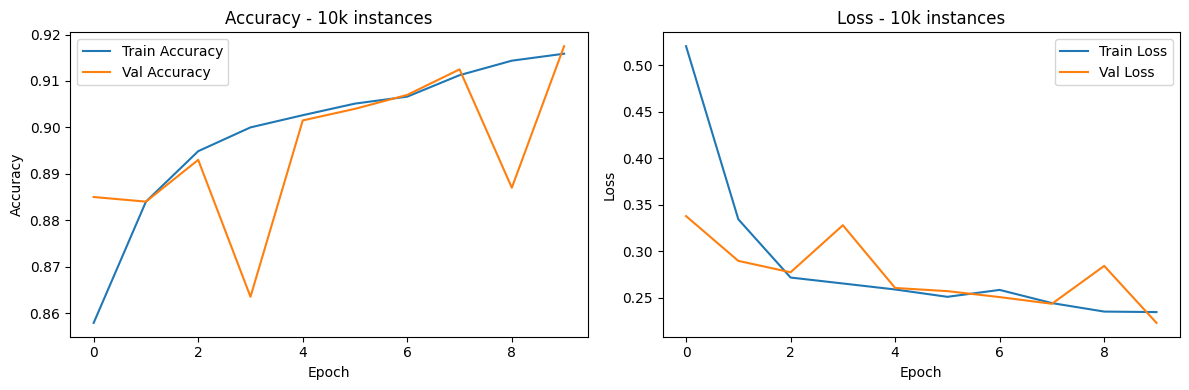

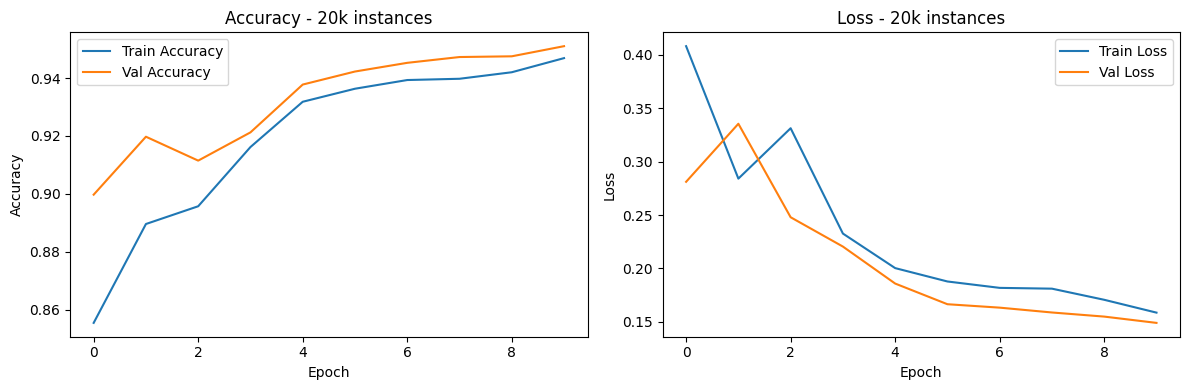

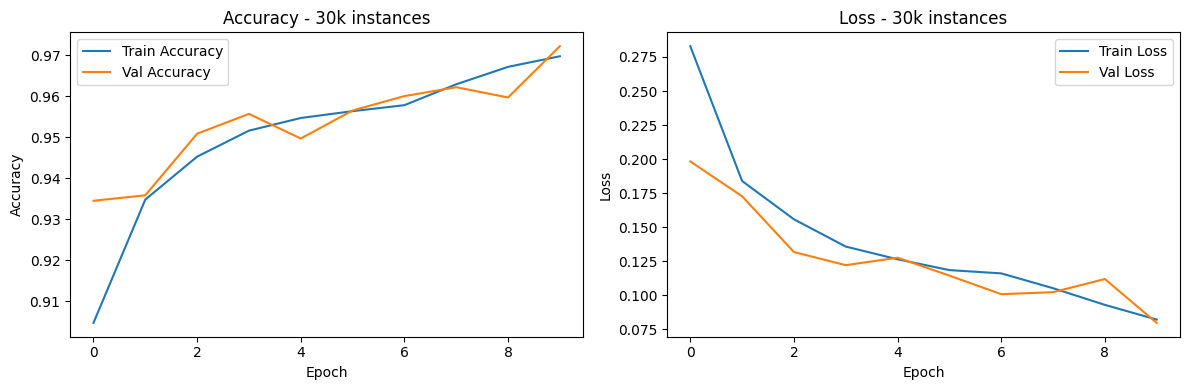

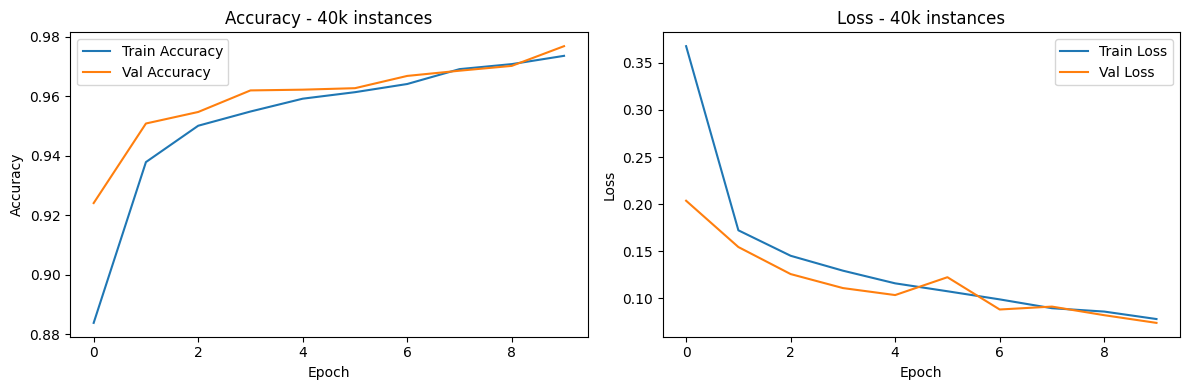

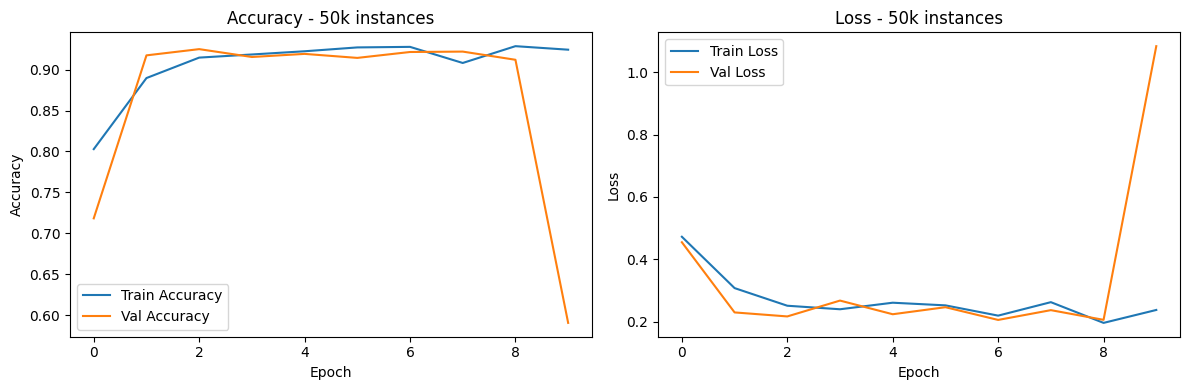

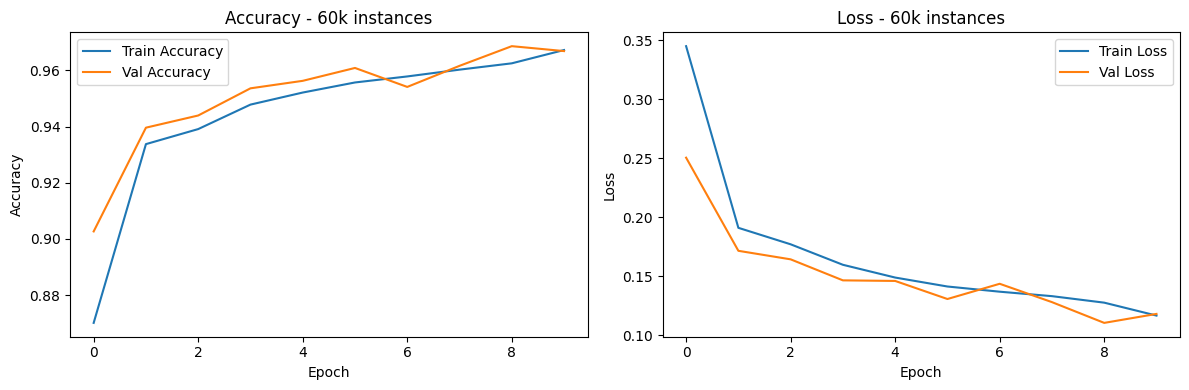

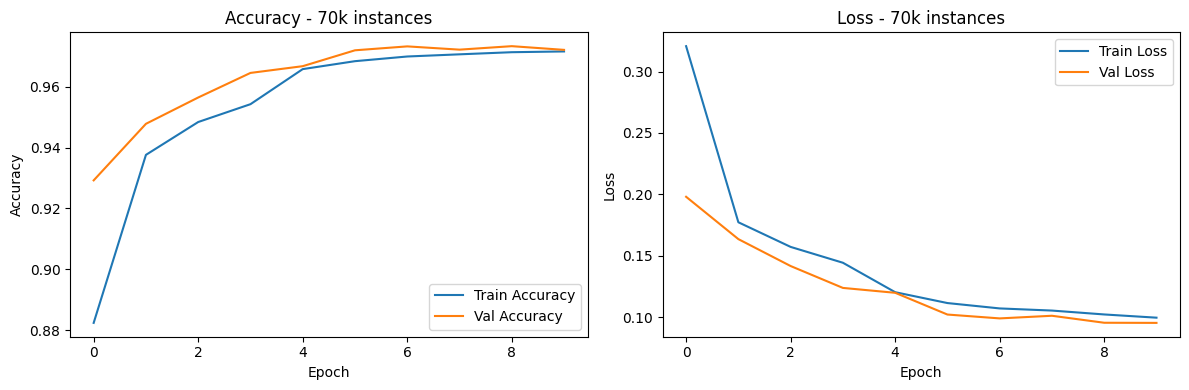

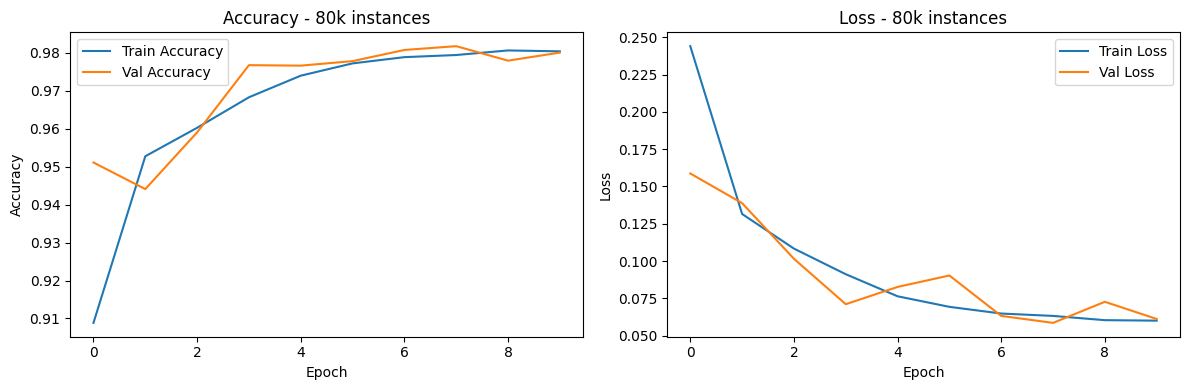

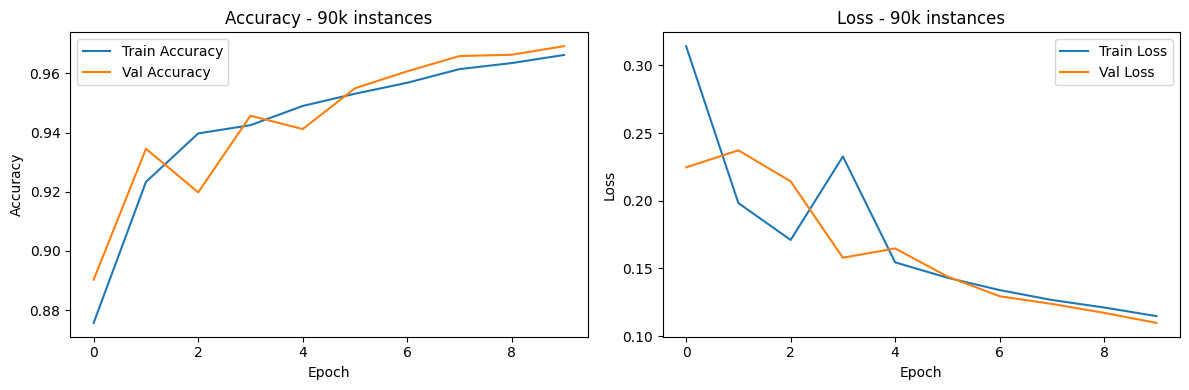

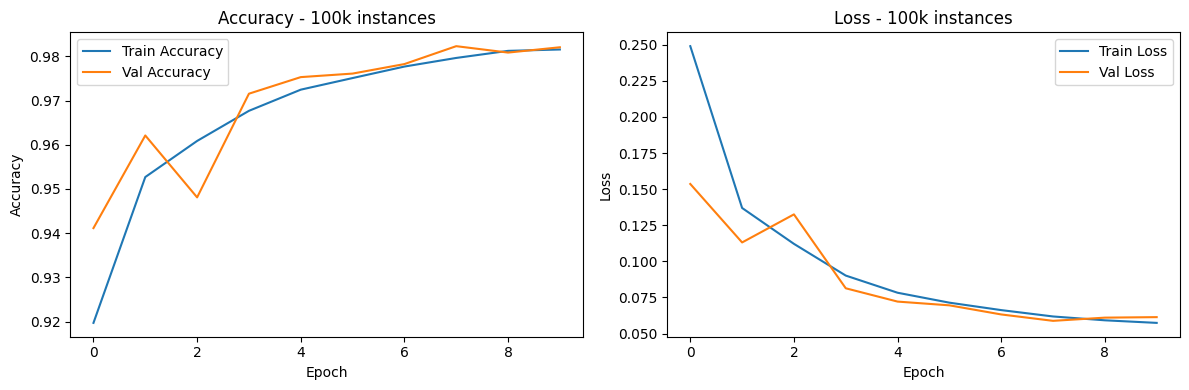

In [17]:
import matplotlib.pyplot as plt

for i, hist in enumerate(results['history']):
    n = results['instances'][i]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(hist['accuracy'], label='Train Accuracy')
    axes[0].plot(hist['val_accuracy'], label='Val Accuracy')
    axes[0].set_title(f'Accuracy - {n//1000}k instances')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(False)

    axes[1].plot(hist['loss'], label='Train Loss')
    axes[1].plot(hist['val_loss'], label='Val Loss')
    axes[1].set_title(f'Loss - {n//1000}k instances')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(False)

    plt.tight_layout()
    plt.show()